# Speech Emotion Recognition using LSTM

This notebook builds an LSTM (Long Short-Term Memory) neural network to detect human emotions from speech audio. The model is trained on the RAVDESS dataset using MFCC, Chroma, and Mel Spectrogram features extracted from voice recordings, then deployed through an interactive Streamlit web app.

**Dataset:** RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)
**Model:** LSTM (Long Short-Term Memory) Neural Network
**Framework:** TensorFlow / Keras, Librosa
**Emotions Detected:** Angry, Calm, Disgust, Fearful, Happy, Neutral, Sad, Surprised
**Test Accuracy:** ~50%

In [1]:
import librosa
import soundfile as sf

print("librosa version:", librosa.__version__)
print("soundfile imported successfully!")

librosa version: 1.0.0
soundfile imported successfully!


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
from tqdm import tqdm

## 1. Loading the RAVDESS Dataset

In [3]:
data_path = "C:\\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRecognition"

emotion_map = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

file_paths = []
emotions = []

for root, dirs, files in os.walk(data_path):
    for file in files:
        if file.endswith(".wav"):
            emotion_code = file.split("-")[2]
            emotion = emotion_map.get(emotion_code)
            if emotion:
                file_paths.append(os.path.join(root, file))
                emotions.append(emotion)

df = pd.DataFrame({"path": file_paths, "emotion": emotions})
print("Total files found:", len(df))
print(df['emotion'].value_counts())
df.head()

Total files found: 1440
emotion
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
neutral       96
Name: count, dtype: int64


,path,emotion
0,C:\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRec...,neutral
1,C:\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRec...,neutral
2,C:\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRec...,neutral
3,C:\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRec...,neutral
4,C:\Users\Fix-Dell\Desktop\CodeAlpha_EmotionRec...,calm


## 2. Audio Data Augmentation

Since the dataset is relatively small (1440 files), we generate additional variations of each audio clip (with noise, pitch shift, and time stretch) to help the model generalize better and reduce overfitting.

In [4]:
def augment_audio(audio, sample_rate):
    augmented_versions = []
    
    augmented_versions.append(audio)
    
    noise = np.random.normal(0, 0.005, audio.shape)
    augmented_versions.append(audio + noise)
    
    pitch_up = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=2)
    augmented_versions.append(pitch_up)
    
    speed_up = librosa.effects.time_stretch(audio, rate=1.1)
    augmented_versions.append(speed_up)
    
    return augmented_versions

## 3. Feature Extraction (MFCC + Chroma + Mel Spectrogram)

We convert each raw audio waveform into numerical features that capture its tone, pitch, and timbre — the acoustic characteristics most relevant to emotion.

In [5]:
def extract_features_from_array(audio, sample_rate, max_len=150):
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
    mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=20)
    
    features = np.vstack([mfcc, chroma, mel])
    
    if features.shape[1] < max_len:
        pad_width = max_len - features.shape[1]
        features = np.pad(features, pad_width=((0,0),(0,pad_width)), mode='constant')
    else:
        features = features[:, :max_len]
    
    return features

## 4. Processing All Audio Files

In [6]:
features = []
labels = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    audio, sample_rate = librosa.load(row['path'], sr=22050)
    
    augmented_versions = augment_audio(audio, sample_rate)
    
    for version in augmented_versions:
        feat = extract_features_from_array(version, sample_rate)
        features.append(feat)
        labels.append(row['emotion'])

X = np.array(features)
y = np.array(labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

C:\Users\Fix-Dell\anaconda3\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
C:\Users\Fix-Dell\anaconda3\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
C:\Users\Fix-Dell\anaconda3\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `hop_length` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
C:\Users\Fix-Dell\anaconda3\Lib\site-packages\librosa\effects.py:448: FutureWarning: The `n_fft` parameter is deprecated as of 1.0 and will be removed in 1.1. It is unused in the current implementation.
  stft_stretch = core.phase_vocoder(
100%|█████████████████████████

X shape: (5760, 72, 150)
y shape: (5760,)


## 5. Encoding Labels and Splitting the Data

In [7]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

y_categorical = to_categorical(y_encoded)

print("Classes:", label_encoder.classes_)
print("y_categorical shape:", y_categorical.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

Classes: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'neutral' 'sad' 'surprised']
y_categorical shape: (5760, 8)
X_train shape: (4608, 72, 150)
X_test shape: (1152, 72, 150)


## 6. Reshaping Data for LSTM

LSTM expects input in the shape (time_steps, features), so we transpose our data accordingly.

In [8]:
X_train = np.transpose(X_train, (0, 2, 1))
X_test = np.transpose(X_test, (0, 2, 1))

print("X_train shape after transpose:", X_train.shape)
print("X_test shape after transpose:", X_test.shape)

X_train shape after transpose: (4608, 150, 72)
X_test shape after transpose: (1152, 150, 72)


## 7. Building the LSTM Model

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(150, X_train.shape[2])),
    Dropout(0.4),
    
    LSTM(32),
    Dropout(0.4),
    
    Dense(16, activation='relu'),
    Dropout(0.3),
    
    Dense(8, activation='softmax')
])

model.summary()

C:\Users\Fix-Dell\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 150, 64)             │          35,072 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 150, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 48,152 (188.09 KB)

 Trainable params: 48,152 (188.09 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Compiling the Model

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 9. Training the Model

We use Early Stopping to prevent overfitting, automatically halting training once validation performance stops improving.

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=60,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop]
)

Epoch 1/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 40s 249ms/step - accuracy: 0.1633 - loss: 2.0565 - val_accuracy: 0.2603 - val_loss: 1.9600
Epoch 2/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 29s 220ms/step - accuracy: 0.2428 - loss: 1.9193 - val_accuracy: 0.2646 - val_loss: 1.8391
Epoch 3/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 191ms/step - accuracy: 0.2896 - loss: 1.8245 - val_accuracy: 0.3145 - val_loss: 1.7136
Epoch 4/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 28s 212ms/step - accuracy: 0.3009 - loss: 1.7787 - val_accuracy: 0.3384 - val_loss: 1.6640
Epoch 5/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 26s 195ms/step - accuracy: 0.3205 - loss: 1.7189 - val_accuracy: 0.3753 - val_loss: 1.6279
Epoch 6/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 41s 198ms/step - accuracy: 0.3364 - loss: 1.7135 - val_accuracy: 0.3753 - val_loss: 1.5967
Epoch 7/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 41s 196ms/step - accuracy: 0.3578 - loss: 1.6562 - val_accuracy: 0.4143 - val_loss: 1.5324
Epoch 8/60
130/130 ━━━━━━━━━━━━━━━━━━━━ 25s 193ms/step - accuracy: 0.3689 - loss: 1

## 10. Evaluating on Test Data

In [12]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step - accuracy: 0.5026 - loss: 1.3252 
Test Accuracy: 50.26%
Test Loss: 1.3252


## 11. Confusion Matrix and Detailed Analysis

36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 75ms/step  


C:\Users\Fix-Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Fix-Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Fix-Dell\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

       angry       0.90      0.65      0.76       153
        calm       0.56      0.69      0.62       153
     disgust       0.58      0.66      0.62       154
     fearful       0.67      0.23      0.35       154
       happy       0.40      0.42      0.41       154
     neutral       0.00      0.00      0.00        77
         sad       0.25      0.37      0.30       153
   surprised       0.48      0.75      0.58       154

    accuracy                           0.50      1152
   macro avg       0.48      0.47      0.45      1152
weighted avg       0.51      0.50      0.48      1152



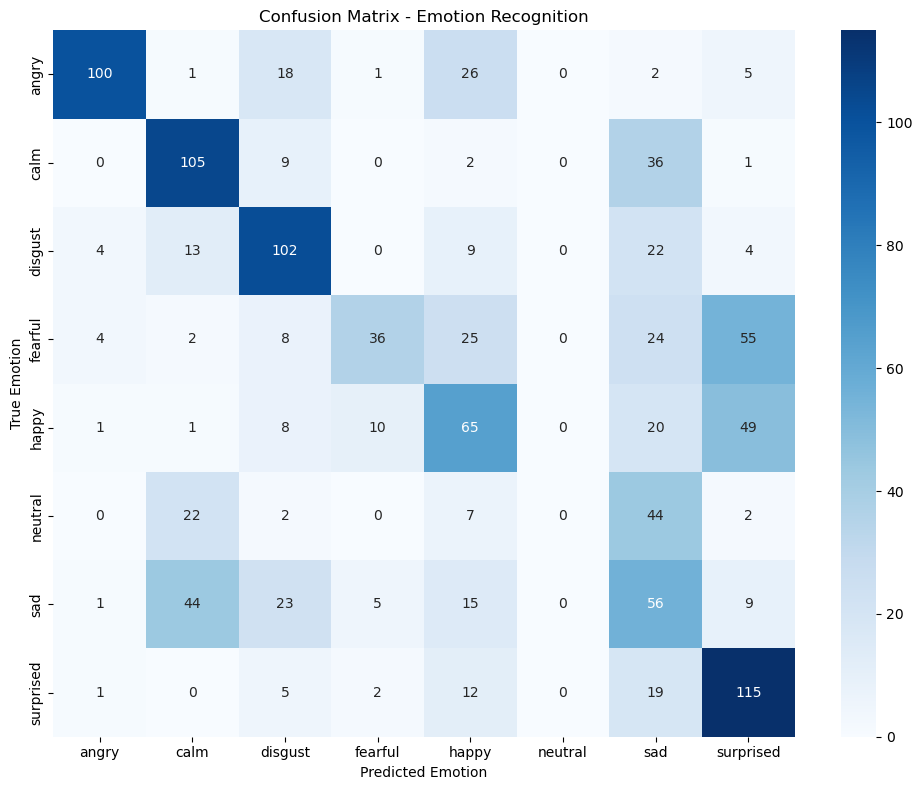

In [13]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# We use all test data.
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Print a detailed report
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Draw Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.xlabel('Predicted Emotion')
plt.ylabel('True Emotion')
plt.title('Confusion Matrix - Emotion Recognition')
plt.tight_layout()
plt.show()

## 12. Saving the Model

In [14]:
import joblib

# Save Model
model.save('emotion_recognition_model.h5')

# Save the Label Encoder (so we can convert the numbers back into emotion names)
joblib.dump(label_encoder, 'label_encoder.pkl')

print("Saved Successfully!")

Saved Successfully!


## 13. Building the Streamlit Web App

In [15]:
app_code = '''import streamlit as st
import numpy as np
import librosa
from tensorflow import keras
import joblib

st.set_page_config(
    page_title="Emotion from Voice",
    page_icon="🎧",
    layout="centered",
    initial_sidebar_state="collapsed"
)

st.markdown("""
    <style>
    @import url("https://fonts.googleapis.com/css2?family=Nunito:wght@400;600;700;800;900&display=swap");

    html, body, [class*="css"] {
        font-family: "Nunito", sans-serif;
    }

    .stApp {
        background: linear-gradient(180deg, #fff7ed 0%, #ffedd5 100%);
    }

    #MainMenu, footer, header {visibility: hidden;}

    .hero {
        text-align: center;
        padding: 2rem 0 0.5rem 0;
    }
    .hero-icon {
        font-size: 3rem;
        margin-bottom: 0.5rem;
    }
    .hero h1 {
        font-size: 2.2rem;
        font-weight: 900;
        color: #9a3412;
        margin-bottom: 0.3rem;
    }
    .hero p {
        color: #c2410c;
        font-size: 1rem;
        font-weight: 600;
        opacity: 0.75;
    }

    .card {
        background: #ffffff;
        border-radius: 22px;
        padding: 1.8rem;
        margin-top: 1.2rem;
        box-shadow: 0 10px 30px rgba(154, 52, 18, 0.08);
        border: 2px solid #ffedd5;
    }

    .card-title {
        font-size: 1rem;
        font-weight: 800;
        color: #9a3412;
        margin-bottom: 0.8rem;
        display: flex;
        align-items: center;
        gap: 0.4rem;
    }

    div.stButton > button {
        width: 100%;
        background: linear-gradient(90deg, #fb923c, #f97316);
        color: white;
        font-weight: 800;
        font-size: 1.05rem;
        padding: 0.75rem;
        border-radius: 14px;
        border: none;
        box-shadow: 0 6px 18px rgba(249, 115, 22, 0.35);
        transition: all 0.2s ease;
    }
    div.stButton > button:hover {
        transform: scale(1.02);
        box-shadow: 0 8px 22px rgba(249, 115, 22, 0.5);
        color: white;
    }

    .result-hero {
        text-align: center;
        padding: 1.5rem 0 0.5rem 0;
    }
    .result-emoji {
        font-size: 4.5rem;
        line-height: 1;
    }
    .result-label {
        font-size: 2rem;
        font-weight: 900;
        color: #9a3412;
        text-transform: capitalize;
        margin-top: 0.3rem;
    }
    .result-conf {
        color: #c2410c;
        font-weight: 700;
        font-size: 0.95rem;
        opacity: 0.8;
    }

    .prob-row {
        display: flex;
        align-items: center;
        gap: 0.8rem;
        margin: 0.5rem 0;
    }
    .prob-emoji {
        font-size: 1.3rem;
        width: 28px;
    }
    .prob-name {
        width: 90px;
        font-weight: 700;
        color: #7c2d12;
        font-size: 0.85rem;
        text-transform: capitalize;
    }
    .prob-track {
        flex: 1;
        background: #ffedd5;
        border-radius: 10px;
        height: 14px;
        overflow: hidden;
    }
    .prob-fill {
        height: 100%;
        border-radius: 10px;
        background: linear-gradient(90deg, #fdba74, #f97316);
    }
    .prob-pct {
        width: 45px;
        text-align: right;
        font-size: 0.8rem;
        font-weight: 700;
        color: #9a3412;
    }

    .placeholder {
        text-align: center;
        padding: 2.5rem 1rem;
        color: #c2703c;
        font-weight: 600;
        font-size: 0.9rem;
    }

    .footer-note {
        text-align: center;
        color: #c2703c;
        font-size: 0.78rem;
        margin-top: 2rem;
        padding-bottom: 1rem;
        font-weight: 600;
        opacity: 0.7;
    }

    [data-testid="stFileUploader"] {
        background: #fff7ed;
        border-radius: 14px;
        padding: 0.8rem;
        border: 2px dashed #fdba74;
    }
    </style>
""", unsafe_allow_html=True)

model = keras.models.load_model("emotion_recognition_model.h5")
label_encoder = joblib.load("label_encoder.pkl")

EMOTION_EMOJIS = {
    "angry": "😠", "calm": "😌", "disgust": "🤢", "fearful": "😨",
    "happy": "😄", "neutral": "😐", "sad": "😢", "surprised": "😲"
}

def extract_features(audio, sample_rate, max_len=150):
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
    mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=20)
    features = np.vstack([mfcc, chroma, mel])
    if features.shape[1] < max_len:
        pad_width = max_len - features.shape[1]
        features = np.pad(features, pad_width=((0,0),(0,pad_width)), mode="constant")
    else:
        features = features[:, :max_len]
    return features

st.markdown("""
    <div class="hero">
        <div class="hero-icon">🎧</div>
        <h1>What does your voice say?</h1>
        <p>Upload a voice clip and discover the emotion behind it</p>
    </div>
""", unsafe_allow_html=True)

st.markdown("<div class=\\'card\\'>", unsafe_allow_html=True)
st.markdown("<div class=\\'card-title\\'>🎵 Your Audio</div>", unsafe_allow_html=True)
uploaded_file = st.file_uploader("Choose a .wav file", type=["wav"], label_visibility="collapsed")
if uploaded_file is not None:
    st.audio(uploaded_file, format="audio/wav")
predict_clicked = st.button("🔍 Analyze Emotion")
st.markdown("</div>", unsafe_allow_html=True)

st.markdown("<div class=\\'card\\'>", unsafe_allow_html=True)

if predict_clicked and uploaded_file is not None:
    audio, sample_rate = librosa.load(uploaded_file, sr=22050)
    feat = extract_features(audio, sample_rate)
    feat = np.transpose(feat, (1, 0))
    feat = feat.reshape(1, feat.shape[0], feat.shape[1])

    prediction = model.predict(feat, verbose=0)[0]
    predicted_class = np.argmax(prediction)
    predicted_emotion = label_encoder.classes_[predicted_class]
    confidence = float(np.max(prediction) * 100)
    emoji = EMOTION_EMOJIS.get(predicted_emotion, "")

    st.markdown(f"""
        <div class="result-hero">
            <div class="result-emoji">{emoji}</div>
            <div class="result-label">{predicted_emotion}</div>
            <div class="result-conf">{confidence:.1f}% confidence</div>
        </div>
    """, unsafe_allow_html=True)

    st.markdown("<div class=\\'card-title\\' style=\\'margin-top:1rem;\\'>📊 Full Breakdown</div>", unsafe_allow_html=True)

    sorted_pairs = sorted(zip(label_encoder.classes_, prediction), key=lambda x: x[1], reverse=True)

    for emotion, prob in sorted_pairs:
        pct = prob * 100
        emo_icon = EMOTION_EMOJIS.get(emotion, "")
        st.markdown(f"""
            <div class="prob-row">
                <div class="prob-emoji">{emo_icon}</div>
                <div class="prob-name">{emotion}</div>
                <div class="prob-track"><div class="prob-fill" style="width:{pct}%;"></div></div>
                <div class="prob-pct">{pct:.0f}%</div>
            </div>
        """, unsafe_allow_html=True)

elif predict_clicked:
    st.warning("Please upload an audio file first.")
else:
    st.markdown("""
        <div class="placeholder">
            🎙️ Upload a .wav file above, then tap<br><b>Analyze Emotion</b> to see the results here.
        </div>
    """, unsafe_allow_html=True)

st.markdown("</div>", unsafe_allow_html=True)

st.markdown("""
    <div class="footer-note">
        Powered by an LSTM neural network trained on the RAVDESS dataset
    </div>
""", unsafe_allow_html=True)
'''

with open("app.py", "w", encoding="utf-8") as f:
    f.write(app_code)

print("Done! New app.py created with a fresh design.")

Done! New app.py created with a fresh design.
